## Clase n° 4 del curso de ML Transformación de los datos

### Proceso de transformación
- Datos crudos
- Transformación
- Datos preparados
- Modelo entrenado

#### Ingenieria de caracteristicas // Feature Engineering
- Creación: Generar nuevas variables a partir de otras.
- Eliminación: Descartar variables que no son de interés.
- Selección: Elegir las variables mas relevantes
- Transformación: Modificar variables para mejroar su utilidad

##### **Mensaje**: no es solo elegir el mejor modelo, sino que las variables tambien son importante para que el modelo nos den bien.


Deteccion de outliers
- Visualizacion:boxplots, histogramas o diagramas de dispersion
- Metodos estadísticos: se puede considerar con estea a +- 3sd o usar rango intercuartilico.
- Detección automatico

### Entrenamiento vs Testeo

#### Regresion lineal simple / multiple
- Permiten predecir valores numericos continuos
- 

In [3]:
# Library
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
print ("librerias ok")

librerias ok


d:\Josefina\Proyectos\Datascience\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
# Leemos el dataset generado anteriormente
df = pd.read_csv("./data/AmesHousing_modificado.csv")
df.head
print(df.shape)

(2930, 23)


In [30]:
df_model = df.copy()

In [31]:
# Eliminar NA (o imputar después)
df_model = df_model.dropna()

In [32]:
# Pasar las variables categoricas a numericas de alguna forma
mapping_Kitchen = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5 }
df_model["Kitchen Qual"] = df_model["Kitchen Qual"].map(mapping_Kitchen)

mapping_exter = {"Fa": 1, "TA": 2, "Gd": 3, "Ex": 4}
df_model["Exter Qual"] = df_model["Exter Qual"].map(mapping_exter)

mapping_Bsmt = {"Po": 1,"Fa": 2,"TA": 3,"Gd": 4,"Ex": 5}
df_model["Bsmt Qual"] = df_model["Bsmt Qual"].map(mapping_Bsmt)

# One-Hot Encoding porque no hay un orden en ellas
df_model = pd.get_dummies(df_model, columns=["House Style"], drop_first=True)

df_model = pd.get_dummies(df_model, columns=["Foundation"], drop_first=True)
mapping_garage = {"Unf": 1, "RFn": 2, "Fin": 3 }
df_model["Garage Finish"] = df_model["Garage Finish"].map(mapping_garage)

df_model = pd.get_dummies(df_model, columns = ["Sale Condition"], drop_first = True, dtype=int)
df_model = pd.get_dummies(df_model, columns = ["Neighborhood"], drop_first = True, dtype = int)

In [33]:
# Variable objetivo
y = df_model["SalePrice"]

# Variables predictoras
X = df_model.drop(columns="SalePrice")


print(f"Cantidad de observaciones: {len(df_model)}")
print(f"Número de variables predictoras: {X.shape[1]}")

X.head()

Cantidad de observaciones: 2223
Número de variables predictoras: 59


,Unnamed: 0,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Year Built,Year Remod/Add,Full Bath,Mas Vnr Area,Fireplaces,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,0,6,1656,1080.0,528.0,1960,1960,1,112.0,2,...,0,0,0,0,0,0,0,0,0,0
1,1,5,896,882.0,730.0,1961,1961,1,0.0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,6,1329,1329.0,312.0,1958,1958,1,108.0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,7,2110,2110.0,522.0,1968,1968,2,0.0,2,...,0,0,0,0,0,0,0,0,0,0
4,4,5,1629,928.0,482.0,1997,1998,2,0.0,1,...,0,0,0,0,0,0,0,0,0,0


In [34]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 2223 entries, 0 to 2929
Data columns (total 60 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              2223 non-null   int64  
 1   SalePrice               2223 non-null   int64  
 2   Overall Qual            2223 non-null   int64  
 3   Gr Liv Area             2223 non-null   int64  
 4   Total Bsmt SF           2223 non-null   float64
 5   Garage Area             2223 non-null   float64
 6   Year Built              2223 non-null   int64  
 7   Year Remod/Add          2223 non-null   int64  
 8   Full Bath               2223 non-null   int64  
 9   Mas Vnr Area            2223 non-null   float64
 10  Fireplaces              2223 non-null   int64  
 11  Lot Area                2223 non-null   int64  
 12  Lot Frontage            2223 non-null   float64
 13  Wood Deck SF            2223 non-null   int64  
 14  Open Porch SF           2223 non-null   int64  
 15  Kit

In [35]:
#Ahora si vamos a dividir
# Entrenamiento 80% - 20% testeo
# random_state, es una semilla aleatorio
X_Train,X_Test, Y_Train,Y_Test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#Veo la longitud
print(f"Datos para entrenar {X_Train.shape[0]} pasajeros")
print(f"Datos para testear {X_Test.shape[0]} pasajeros")

Datos para entrenar 1778 pasajeros
Datos para testear 445 pasajeros


In [36]:
#Entrenar modelo
#Genero el modelo
modelo = LinearRegression ()

#Entreno el modelo con mis datos
modelo.fit(X_Train, Y_Train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
# Ahora hay que hacer la prediccion porque el modelo ya esta entrenado
predicciones_train = modelo.predict(X_Train) #visto por el modelo original
predicciones_test = modelo.predict(X_Test) #no visto por el modelo original

In [38]:
# Calculamos metricas estadisticas
#Se calcula el Error Absoluto Medio
mae_train = mean_absolute_error (Y_Train, predicciones_train)
mae_test = mean_absolute_error (Y_Test, predicciones_test)

#Calcular r2 (que porcentaje del problema se entendio)
r2_train = r2_score(Y_Train, predicciones_train)
r2_test = r2_score(Y_Test, predicciones_test)


#Calcular RMSE: con la raiz cuadrada del MSE
rmse_train =np.sqrt(mean_squared_error(Y_Train, predicciones_train))
rmse_test =np.sqrt(mean_squared_error(Y_Test, predicciones_test))


### Hacer print para ver las metricas
print(f"Error promedio del train: {round(mae_train,2)}") # se esta equivocando el boleto en $24.3
print(f"Error promedio del test: {round(mae_test,2)}") # se esta equivocando el boleto en $24.85

#Error cuadtatico medio. En general tiene que dar mas grande
print(f"RMSE train: {round(rmse_train,2)}") # se esta equivocando el boleto en $43.45
print(f"RMSE test: {round(rmse_test,2)}")  # se esta equivocando el boleto en $45.3, el modelo esta pifiando bastante


print(f"R2 train: {round(r2_train,2)}")
print(f"R2 test: {round(r2_test,2)}")



Error promedio del train: 19381.86
Error promedio del test: 21391.96
RMSE train: 30608.21
RMSE test: 39031.34
R2 train: 0.86
R2 test: 0.79


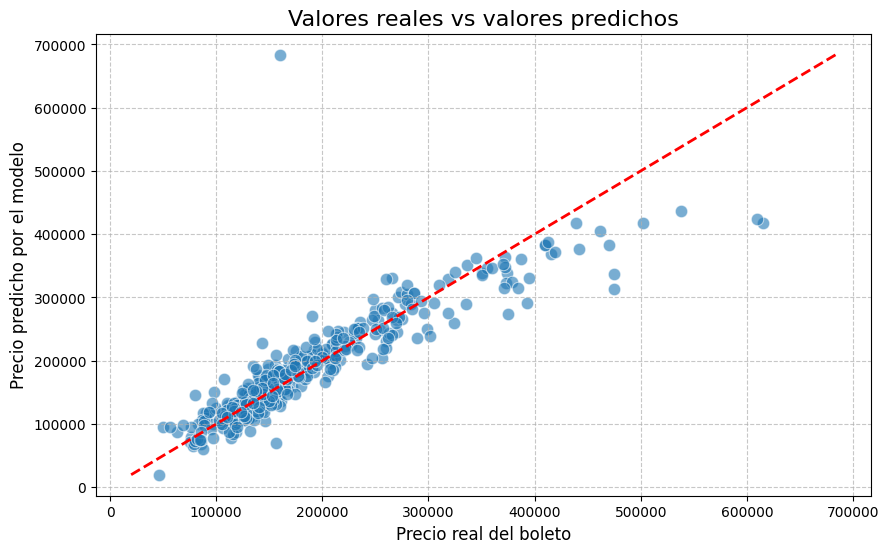

In [39]:
# =============================================================================
# Gráfico de evaluación del modelo: valores reales vs valores predichos
# =============================================================================
# Este gráfico permite evaluar visualmente el desempeño del modelo de regresión.
# Cada punto representa una observación del conjunto de prueba.
# Cuanto más cerca se encuentren los puntos de la línea diagonal (y = x),
# menor será el error de predicción.


# Convertir las estructuras de datos a vectores unidimensionales para facilitar
# su visualización.
y_real = Y_Test.squeeze()
y_pred = predicciones_test.flatten()

# Plot
plt.figure(figsize=(10, 6))

#Valores reales VS los valores predichos
sns.scatterplot(
    x=y_real,
    y=y_pred,
    alpha=0.6,  # Transparencia para mejorar la visualización
    s=80        # Tamaño de los puntos
)

# Calcular los límites del gráfico considerando ambos conjuntos de datos.
# Esto garantiza que la línea de referencia cubra todo el rango observado.
min_val = min(y_real.min(), y_pred.min())
max_val = max(y_real.max(), y_pred.max())

# Dibujar la línea de referencia 1:1
# Los puntos ubicados sobre esta línea representan predicciones exactas.
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2
)

# Configuración estética del gráfico
plt.title("Valores reales vs valores predichos", fontsize=16)
plt.xlabel("Precio real del boleto", fontsize=12)
plt.ylabel("Precio predicho por el modelo", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

# Mostrar gráfico
plt.show()